# Notebook 06_figures — Figure finali per la tesi

## Obiettivi
Questo notebook non introduce nuove analisi statistiche: riprende il panel integrato costruito in `05_model` (`panel_finale.parquet`) e ne produce le figure finali ad alta risoluzione da inserire in tesi. Nello specifico:
- heatmap coorte × anno di attività, per osservare come cambia la diversità a seconda di *quando* un utente ha iniziato a usare la piattaforma. 
  (coorte) e di *quanto* tempo vi è rimasto attivo
- scatter tra anzianità sulla piattaforma e diversità media, a livello di singolo utente
- calcolo del tasso di rinnovamento aggregato (quota media di novelty nella popolazione, nel tempo)
- salvataggio di tutte le figure in `figures/`, in formato PNG ad alta risoluzione (300 dpi)

#### Import delle librerie

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

print("Ambiente configurato correttamente")


Ambiente configurato correttamente


#### Definizione dei path

In [2]:
project_root = Path.cwd().parent
data_path = project_root / "data"
processed_path = data_path / "processed"
figures_path = project_root / "figures"
figures_path.mkdir(exist_ok=True)

FIG_DPI = 300  # risoluzione più alta di quella usata nei notebook precedenti (200)

print("Project root:", project_root)
print("Processed path:", processed_path)
print("Figures path:", figures_path)

Project root: /Users/sofiadimaggio/Desktop/uni/3 anno/Tirocinio_MovieLens
Processed path: /Users/sofiadimaggio/Desktop/uni/3 anno/Tirocinio_MovieLens/data/processed
Figures path: /Users/sofiadimaggio/Desktop/uni/3 anno/Tirocinio_MovieLens/figures


### Caricamento del panel e definizione delle coorti

Viene caricato `panel_finale.parquet` (costruito in `05_model`). La coorte di un utente è definita, come in `02_EDA`, dal primo anno di attività osservato (`cohort_year = min(year)` per utente). Dato che non è stata salvata nel parquet, la ricalcolo qui.

In [3]:
panel = pd.read_parquet(processed_path / "panel_finale.parquet")

panel["cohort_year"] = panel.groupby("userId")["year"].transform("min")

print("Panel caricato:", panel.shape)
print("Numero di coorti (anni di primo utilizzo) distinte:", panel["cohort_year"].nunique())
panel[["userId", "year", "active_year", "cohort_year"]].head()

Panel caricato: (35624, 38)
Numero di coorti (anni di primo utilizzo) distinte: 23


,userId,year,active_year,cohort_year
0,3,2015,1,2015
1,3,2016,2,2015
2,3,2017,3,2015
3,3,2019,4,2015
4,5,1996,1,1996


### Heatmap coorte × anno di attività
Per ciascuna combinazione (coorte, anno di attività) si calcola la Genre Diversity media. Le coorti con pochissimi utenti/osservazioni vengono escluse per evitare medie poco affidabili basate su pochi punti (soglia: almeno 30 osservazioni utente-anno nella cella).

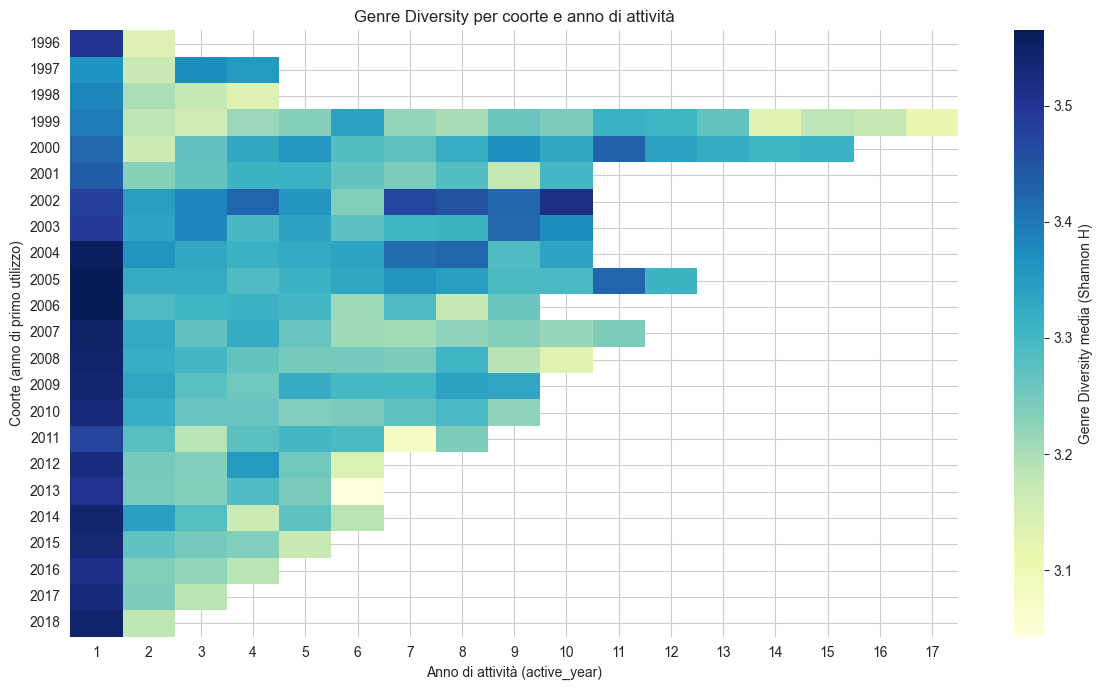

In [4]:
cohort_active_counts = (
    panel.groupby(["cohort_year", "active_year"])
    .size()
    .reset_index(name="n_obs")
)

cohort_entropy = (
    panel.groupby(["cohort_year", "active_year"])["entropy"]
    .mean()
    .reset_index()
    .merge(cohort_active_counts, on=["cohort_year", "active_year"])
)

MIN_OBS = 30
cohort_entropy_filtered = cohort_entropy[cohort_entropy["n_obs"] >= MIN_OBS]

heatmap_data = cohort_entropy_filtered.pivot(
    index="cohort_year", columns="active_year", values="entropy"
)

plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_data, cmap="YlGnBu", annot=False,
    cbar_kws={"label": "Genre Diversity media (Shannon H)"}
)
plt.title("Genre Diversity per coorte e anno di attività")
plt.xlabel("Anno di attività (active_year)")
plt.ylabel("Coorte (anno di primo utilizzo)")
plt.tight_layout()
plt.savefig(figures_path / "heatmap_cohort_entropy.png", dpi=FIG_DPI)
plt.show()

Le celle vuote (bianche) corrispondono a combinazioni coorte/anno di attività senza abbastanza osservazioni (coorti giovani non hanno ancora accumulato molti anni di attività).
Coorti molto vecchie hanno pochi utenti sopravvissuti a lungo, il che è normale ed è quello che ci aspettiamo, non è un errore.
La heatmap va letta per righe (come evolve la stessa coorte nel tempo) più che per colonne, dato che il confronto tra coorti a parità di anno di attività può risentire di composizione diversa del campione.

**NB:** 
La prima colonna (`active_year = 1`) è la più scura per quasi tutte le coorti: a un primo sguardo potrebbe sembrare che la diversità *diminuisca* con l'anzianità, mentre il modello a effetti fissi di `05_model` trova un coefficiente *positivo*
(+0.0065) su `active_year`. Non è una contraddizione: guardando la traiettoria aggregata (grafico "Traiettorie medie
per active_year" di `05_model`), il primo anno mostra un **picco isolato** (H ≈ 3.50), seguito da un crollo al
secondo anno (H ≈ 3.26) e poi da una **crescita genuina e graduale** dal secondo anno in poi fino a un massimo
intorno all'anno 8-12. Il coefficiente positivo della FE riflette soprattutto questa crescita a partire dal secondo
anno, non il primo anno preso isolatamente. Il picco al primo anno è un artefatto tipico dei dataset MovieLens: molti utenti, appena si iscrivono, valutano in blocco un ampio numero di film già visti in passato (un "rating dump" iniziale, eterogeneo per costruzione), un comportamento diverso dal consumo abituale degli anni successivi.

#### La stessa heatmap per la Geographic Diversity, per confronto

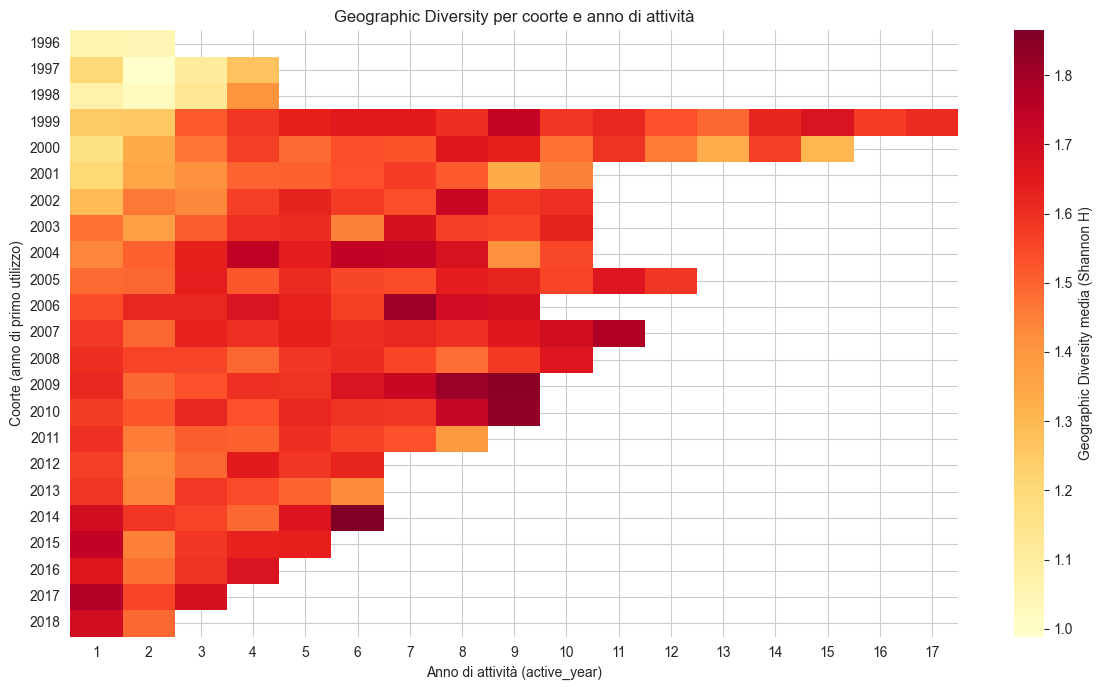

In [5]:
cohort_geo = (
    panel.groupby(["cohort_year", "active_year"])["geo_entropy"]
    .mean()
    .reset_index()
    .merge(cohort_active_counts, on=["cohort_year", "active_year"])
)
cohort_geo_filtered = cohort_geo[cohort_geo["n_obs"] >= MIN_OBS]

heatmap_geo = cohort_geo_filtered.pivot(
    index="cohort_year", columns="active_year", values="geo_entropy"
)

plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_geo, cmap="YlOrRd", annot=False,
    cbar_kws={"label": "Geographic Diversity media (Shannon H)"}
)
plt.title("Geographic Diversity per coorte e anno di attività")
plt.xlabel("Anno di attività (active_year)")
plt.ylabel("Coorte (anno di primo utilizzo)")
plt.tight_layout()
plt.savefig(figures_path / "heatmap_cohort_geo_entropy.png", dpi=FIG_DPI)
plt.show()

### Scatter: anzianità sulla piattaforma vs diversità media (per utente)
A differenza della regressione a effetti fissi (che sfrutta la variazione *entro* utente nel tempo), qui si guarda la relazione *tra* utenti: chi resta di più sulla piattaforma (più anni attivi totali) ha, in media, una diversità di generi più alta o più bassa? Per ogni utente si calcola: il numero totale di anni attivi osservati (`tenure`) e la sua Genre Diversity media su tutti gli anni.

In [6]:
user_summary = (
    panel.groupby("userId")
    .agg(
        tenure=("active_year", "max"),
        entropy_mean=("entropy", "mean"),
        geo_entropy_mean=("geo_entropy", "mean"),
        n_ratings_total=("n_ratings_year", "sum"),
        activity_group=("activity_group", "first"),
    )
    .reset_index()
)

print("Utenti nel riepilogo:", user_summary.shape[0])
user_summary.head()

Utenti nel riepilogo: 10000


,userId,tenure,entropy_mean,geo_entropy_mean,n_ratings_total,activity_group
0,3,4,3.581432,1.775247,2005,High
1,5,2,3.499538,0.640140,250,Low
2,19,2,3.699598,2.328761,1369,High
3,36,2,3.529742,1.306065,295,Low
4,38,2,3.641667,2.105848,779,Medium


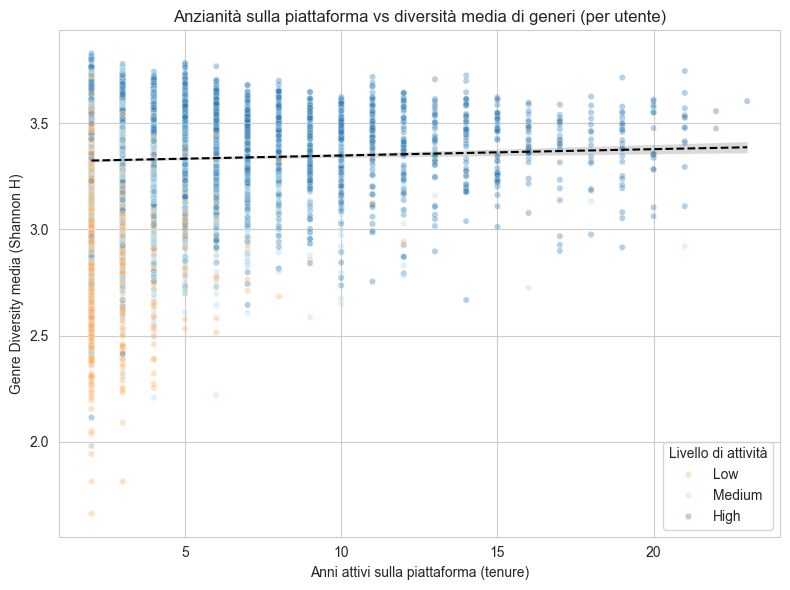

Correlazione (tenure, entropy_mean): 0.03142752591990465


In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=user_summary, x="tenure", y="entropy_mean",
    hue="activity_group", alpha=0.35, s=20,
    palette={"Low": "#fdae61", "Medium": "#abd9e9", "High": "#2c7bb6"}
)

# retta di tendenza (regressione lineare semplice, solo descrittiva)
sns.regplot(
    data=user_summary, x="tenure", y="entropy_mean",
    scatter=False, color="black", line_kws={"linestyle": "--", "linewidth": 1.5}
)

plt.xlabel("Anni attivi sulla piattaforma (tenure)")
plt.ylabel("Genre Diversity media (Shannon H)")
plt.title("Anzianità sulla piattaforma vs diversità media di generi (per utente)")
plt.legend(title="Livello di attività")
plt.tight_layout()
plt.savefig(figures_path / "scatter_tenure_vs_entropy.png", dpi=FIG_DPI)
plt.show()

print("Correlazione (tenure, entropy_mean):", user_summary[["tenure", "entropy_mean"]].corr().iloc[0, 1])

Qui sto confrontando utenti diversi tra loro (chi resta più a lungo ha, in media, una diversità più alta?), mentre il modello a
effetti fissi rispondeva a una domanda diversa (lo stesso utente diversifica di più con il passare degli anni?). <br>
Le due prospettive possono dare risultati compatibili ma non sono la stessa cosa: qui entra in gioco anche la selezione: gli utenti che restano più a lungo potrebbero essere sistematicamente diversi (più curiosi, più attivi) da quelli che abbandonano presto, e questo grafico da solo non permette di distinguere le due spiegazioni.

Numericamente, la correlazione tra tenure ed entropy_mean è quasi nulla (r = 0.031): coerente con l'effect size già piccolo trovato in `05_model` (0.16 deviazioni standard su 10 anni). La relazione è nella direzione attesa ma debole, altri fattori (es. volume di consumo, genere di appartenenza dei contenuti disponibili nel periodo) contano di più della sola anzianità.

### Tasso di rinnovamento aggregato

Il tasso di rinnovamento aggregato sintetizza, per ciascun anno di calendario, quanto in media il consumo della popolazione campionata introduce generi realmente nuovi rispetto alla storia individuale di ciascun utente (media di `novelty_pct` su tutti gli utenti attivi in quell'anno, escluso il primo anno di attività di ciascuno, per lo stesso motivo discusso in `05_model`).

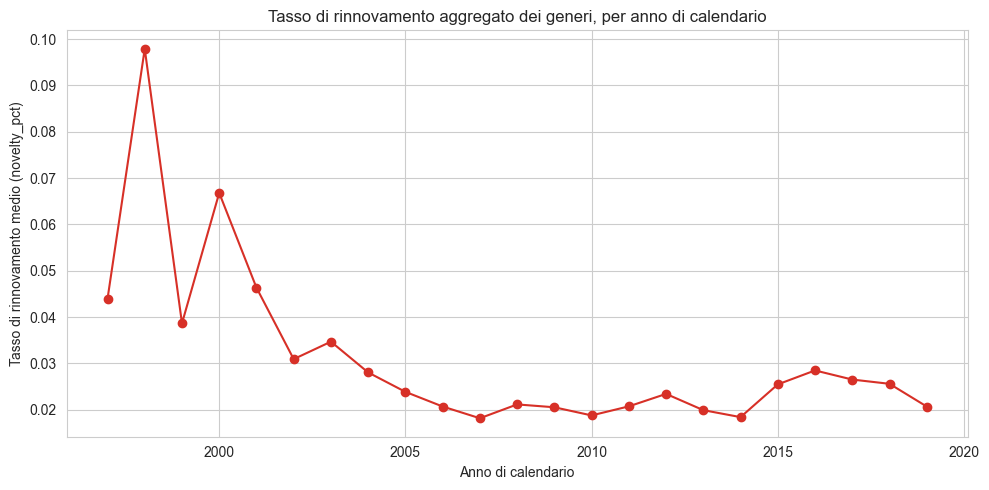

Tasso di rinnovamento aggregato complessivo (tutti gli anni, active_year >= 2): 2.7%


In [8]:
renewal_by_year = (
    panel[panel["active_year"] >= 2]
    .groupby("year")["novelty_pct"]
    .mean()
    .reset_index(name="renewal_rate")
)

plt.figure(figsize=(10, 5))
plt.plot(renewal_by_year["year"], renewal_by_year["renewal_rate"], marker="o", color="#d73027")
plt.xlabel("Anno di calendario")
plt.ylabel("Tasso di rinnovamento medio (novelty_pct)")
plt.title("Tasso di rinnovamento aggregato dei generi, per anno di calendario")
plt.tight_layout()
plt.savefig(figures_path / "renewal_rate_by_year.png", dpi=FIG_DPI)
plt.show()

overall_renewal_rate = panel.loc[panel["active_year"] >= 2, "novelty_pct"].mean()
print(f"Tasso di rinnovamento aggregato complessivo (tutti gli anni, active_year >= 2): {overall_renewal_rate:.1%}")

/var/folders/v9/sc0zytp57wjg3y5wqw9xfc480000gn/T/ipykernel_72724/760484069.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("activity_group")["novelty_pct"]


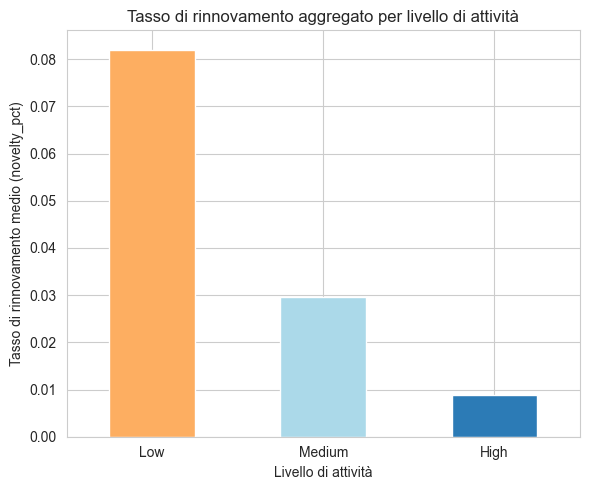

activity_group
Low       0.081995
Medium    0.029532
High      0.008843
Name: novelty_pct, dtype: float64

In [9]:
renewal_by_group = (
    panel[panel["active_year"] >= 2]
    .groupby("activity_group")["novelty_pct"]
    .mean()
    .reindex(["Low", "Medium", "High"])
)

plt.figure(figsize=(6, 5))
renewal_by_group.plot(kind="bar", color=["#fdae61", "#abd9e9", "#2c7bb6"])
plt.ylabel("Tasso di rinnovamento medio (novelty_pct)")
plt.xlabel("Livello di attività")
plt.title("Tasso di rinnovamento aggregato per livello di attività")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(figures_path / "renewal_rate_by_activity_group.png", dpi=FIG_DPI)
plt.show()

renewal_by_group

Il confronto per livello di attività va letto con cautela: gli utenti "High" guardano più film per anno, quindi hanno statisticamente più occasioni di esaurire rapidamente i 19 generi disponibili (effetto soffitto), il che tende meccanicamente ad abbassare il loro tasso di rinnovamento rispetto agli utenti "Low" anche a parità di reale curiosità verso contenuti nuovi. <br>
Questo è coerente con il coefficiente positivo di `log_ratings` osservato in tutti i modelli FE di `05_model`.

### Riepilogo delle figure prodotte

Tutte le figure sono state salvate in `figures/` a 300 dpi, pronte per l'inserimento in tesi senza
bisogno di rigenerarle:
- `heatmap_cohort_entropy.png`
- `heatmap_cohort_geo_entropy.png`
- `scatter_tenure_vs_entropy.png`
- `renewal_rate_by_year.png`
- `renewal_rate_by_activity_group.png`

A queste si aggiungono, dal notebook `05_model`, `correlation_diversity_metrics.png`,
`trajectories_active_year.png` e `forest_plot_active_year.png`.

In [10]:
saved_figures = sorted(figures_path.glob("*.png"))
print(f"Figure presenti in {figures_path}:")
for f in saved_figures:
    print(" -", f.name)

Figure presenti in /Users/sofiadimaggio/Desktop/uni/3 anno/Tirocinio_MovieLens/figures:
 - correlation_diversity_metrics.png
 - forest_plot_active_year.png
 - heatmap_cohort_entropy.png
 - heatmap_cohort_geo_entropy.png
 - renewal_rate_by_activity_group.png
 - renewal_rate_by_year.png
 - scatter_tenure_vs_entropy.png
 - trajectories_active_year.png


## Conclusioni e chiusura della pipeline quantitativa

Questo notebook chiude la parte quantitativa dell'analisi. Le figure prodotte qui non aggiungono nuovi
risultati statistici rispetto a `05_model`, ma li rendono leggibili a colpo d'occhio per la tesi:

- le **heatmap per coorte** mostrano che l'aumento di diversità osservato nella regressione FE non è un
  artefatto di una singola generazione di utenti, ma un pattern visibile, seppur con intensità diversa, in
  più coorti;
- lo **scatter tenure vs diversità media** offre una prospettiva complementare (tra utenti, non entro
  utente) coerente in direzione con il risultato principale, ma va letto con la cautela di selezione già
  discussa;
- il **tasso di rinnovamento aggregato** conferma su scala di popolazione, anno per anno, il calo di
  novelty osservato nei modelli FE, ed evidenzia come il livello di attività (volume di consumo) sia un
  fattore chiave nel velocizzare l'effetto soffitto.

**Sintesi complessiva della domanda di ricerca.** <br>
"Gli utenti guardano film sempre meno diversificati nel tempo?" <br>
La risposta, sulla base dell'intera pipeline (`01_preproc` → `05_figures`), è **no per la diversità del consumo corrente** (che anzi aumenta, sia per generi sia per paesi), mentre è **sì per la propensione a scoprire contenuti realmente nuovi** (che diminuisce, con effetto soffitto confermato robusto su più metriche, soglie e tecniche di stima). <br>
Questa distinzione tra *mescolare ciò che si conosce* ed *esplorare ciò che non si conosce* è il contributo interpretativo principale, che andrò a presentare come tale nella discussione finale della tesi, insieme ai limiti già documentati nei notebook precedenti (bias di copertura dei Genome Tags, assenza di identificazione causale di un effetto "algoritmo" rispetto a una naturale evoluzione delle preferenze).